<a href="https://colab.research.google.com/github/ndanilova/Data_Analysis/blob/main/lab1/data_analysis_lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №1
## Уменьшение размерности данных и сравнение методов.
## Дисциплина: Уменьшение размерности данных и сравнение методов.
#### Студент: Данилова Анастасия Алексеевна СИАД K33 1.2


### 1. Цель работы.
Освоить практические навыки работы с методами уменьшения размерности данных, такими как PCA и t-SNE, а также интерпретации их результатов.

**Уменьшение размерности данных** – это подход к упрощению сложных наборов данных путем сокращения количества переменных при сохранении наиболее важной информации. Это позволяет облегчить обработку, анализ и визуализацию данных.

**Метод главных компонент (PCA)** – это линейный метод уменьшения размерности, который ищет направления максимальной дисперсии в данных. Он преобразует исходные переменные в новый набор некоррелированных переменных, называемых главными компонентами.

**t-SNE (t-distributed Stochastic Neighbor Embedding)** – это нелинейный метод уменьшения размерности, который особенно эффективен для визуализации высокоразмерных данных. Он стремится сохранить локальную структуру данных, уделяя особое внимание сохранению близости между точками в пространстве меньшей размерности.

### 2. Задание.
1.	Сбор и предобработка данных: a) Загрузить данные о жанрах музыки (Prediction of music genre). b) Провести предварительную обработку данных:
*	Заменить нечисловые данные на числовые (создать шкалу соответствия);
*	Удалить переменные с нулевой дисперсией;
*	Оставить 10-12 параметров. c) Построить корреляционную матрицу и дать интерпретацию выявленным зависимостям. d) Построить график каменистой осыпи.
2.	Реализация и применение PCA: a) Реализовать алгоритм PCA (можно использовать sklearn.decomposition.PCA). b) Вычислить объясненную дисперсию для каждой компоненты. c) Вычислить процент объясненной дисперсии для первых n компонент. d) Построить проекцию данных на новое пространство;
3.	Реализация и применение t-SNE: a) Реализовать алгоритм t-SNE (можно использовать sklearn.manifold.TSNE). b) Применить t-SNE с разными значениями перплексии. c) Визуализировать результаты;
4.	Сравнительный анализ: a) Сравнить результаты PCA и t-SNE на исследуемых данных. b) Проанализировать преимущества и недостатки каждого метода в контексте ваших данных.


### 3. Выполнение.


In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/ndanilova/Data_Analysis/main/lab1/music_genre.csv"
df = pd.read_csv(url)

print("Размерность данных до предобработки:", df.shape)

# Удаление ненужных столбцов
cols_to_drop = ["instance_id", "artist_name", "track_name", "obtained_date"]
df = df.drop(columns=cols_to_drop, errors="ignore")

categorical_cols = ["key", "mode", "music_genre"]
le_dict = {}

for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le

df = df.replace('?', np.nan)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

feature_candidates = [
    'acousticness', 'danceability', 'duration_ms', 'energy',
    'instrumentalness', 'liveness', 'loudness', 'speechiness',
    'tempo', 'valence', 'popularity', 'key', 'mode'
]

selected_features = [f for f in feature_candidates if f in df.columns]

X = df[selected_features].copy()
y = df['music_genre'] if 'music_genre' in df.columns else None



variances = X.var()
print(f"\nДисперсии признаков:")
for col, var in variances.items():
    print(f"{col}: {var:.6f}")

threshold = 0.01
selector = VarianceThreshold(threshold=threshold)
X_selected = selector.fit_transform(X)

mask = selector.get_support()
selected_columns = X.columns[mask]
X = pd.DataFrame(X_selected, columns=selected_columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_preprocessed = pd.DataFrame(X_scaled, columns=X.columns)

print(f"\nИтоговая размерность данных: {X_preprocessed.shape}")
print(f"Итоговые признаки: {X_preprocessed.columns.tolist()}")



Размерность данных до предобработки: (50005, 18)

Дисперсии признаков:
acousticness: 0.116504
danceability: 0.031906
duration_ms: 16554817432.460150
energy: 0.069985
instrumentalness: 0.105884
liveness: 0.026124
loudness: 37.978988
speechiness: 0.010276
tempo: 845.312099
valence: 0.061062
popularity: 241.529933
key: 11.955626
mode: 0.230093

Итоговая размерность данных: (50005, 13)
Итоговые признаки: ['acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity', 'key', 'mode']


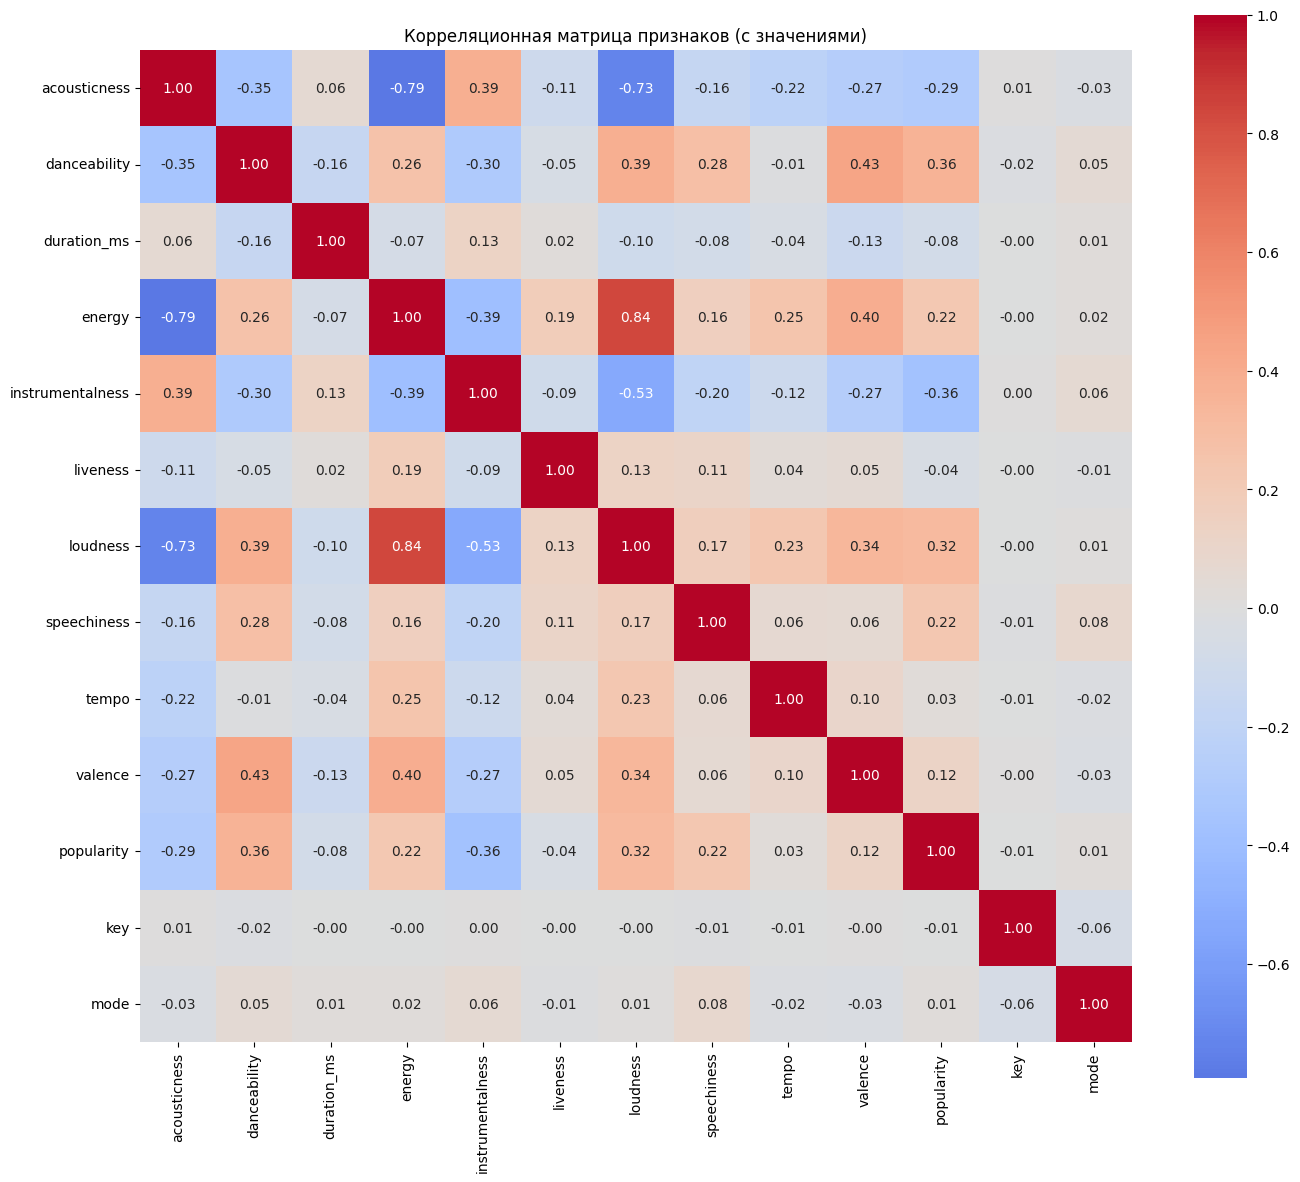

Сильные корреляции (|r| > 0.7):
acousticness - energy: -0.791
acousticness - loudness: -0.730
energy - loudness: 0.838


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))
corr_matrix = X_preprocessed.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f',
            center=0, square=True)
plt.title("Корреляционная матрица признаков (с значениями)")
plt.tight_layout()
plt.show()

strong_correlations = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            strong_correlations.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print("Сильные корреляции (|r| > 0.7):")
for corr in strong_correlations:
    print(f"{corr[0]} - {corr[1]}: {corr[2]:.3f}")

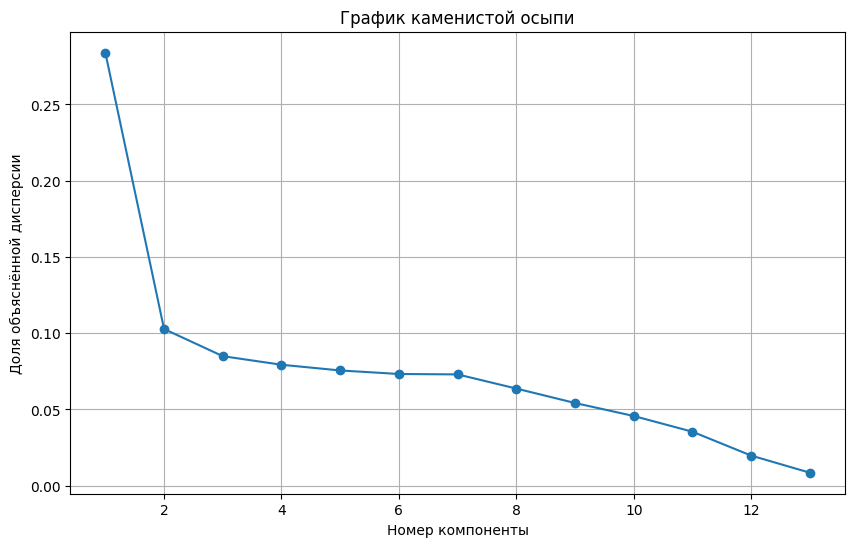

In [15]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_preprocessed)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_, marker='o')
plt.title("График каменистой осыпи")
plt.xlabel("Номер компоненты")
plt.ylabel("Доля объяснённой дисперсии")
plt.grid(True)
plt.show()

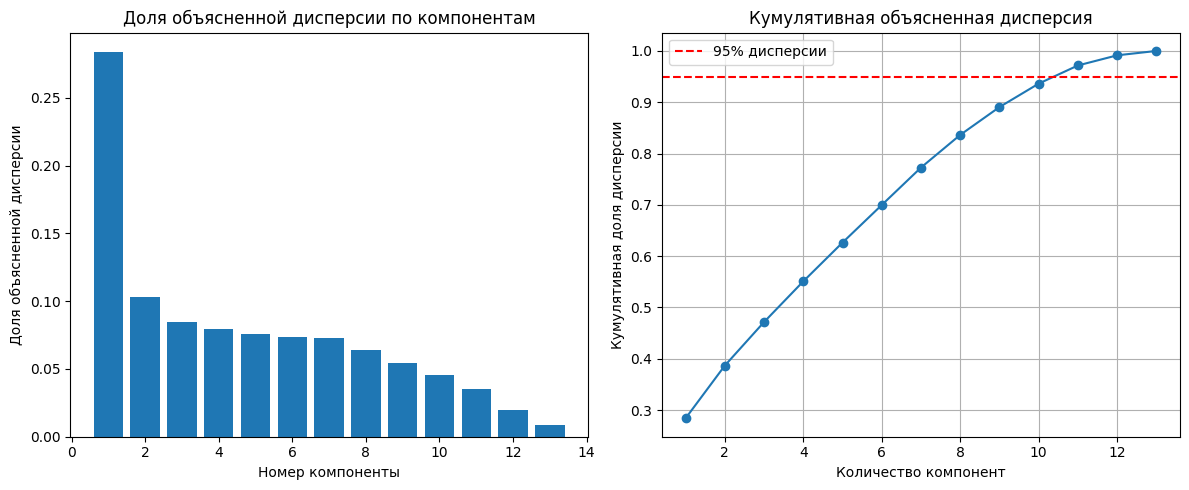

Объясненная дисперсия по компонентам:
PC1: 0.284 (28.4%)
PC2: 0.103 (10.3%)
PC3: 0.085 (8.5%)
PC4: 0.079 (7.9%)
PC5: 0.076 (7.6%)
PC6: 0.073 (7.3%)
PC7: 0.073 (7.3%)
PC8: 0.064 (6.4%)
PC9: 0.054 (5.4%)
PC10: 0.046 (4.6%)
PC11: 0.035 (3.5%)
PC12: 0.020 (2.0%)
PC13: 0.009 (0.9%)

Кумулятивная объясненная дисперсия:
Первые 1 компонент: 0.284 (28.4%)
Первые 2 компонент: 0.387 (38.7%)
Первые 3 компонент: 0.472 (47.2%)
Первые 4 компонент: 0.551 (55.1%)
Первые 5 компонент: 0.626 (62.6%)
Первые 6 компонент: 0.700 (70.0%)
Первые 7 компонент: 0.773 (77.3%)
Первые 8 компонент: 0.836 (83.6%)
Первые 9 компонент: 0.891 (89.1%)
Первые 10 компонент: 0.936 (93.6%)
Первые 11 компонент: 0.972 (97.2%)
Первые 12 компонент: 0.991 (99.1%)
Первые 13 компонент: 1.000 (100.0%)


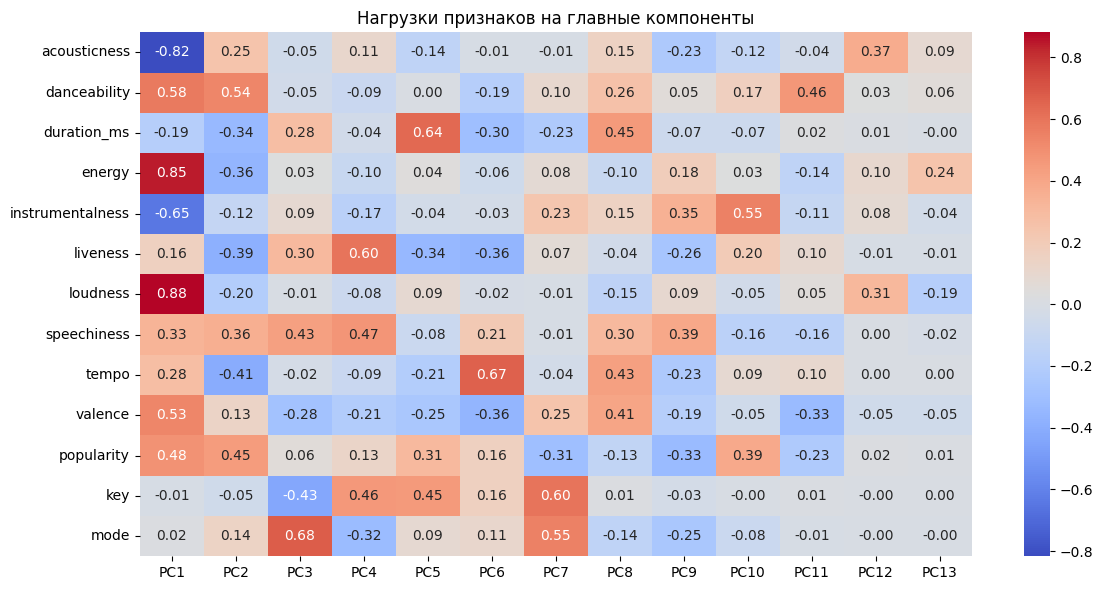

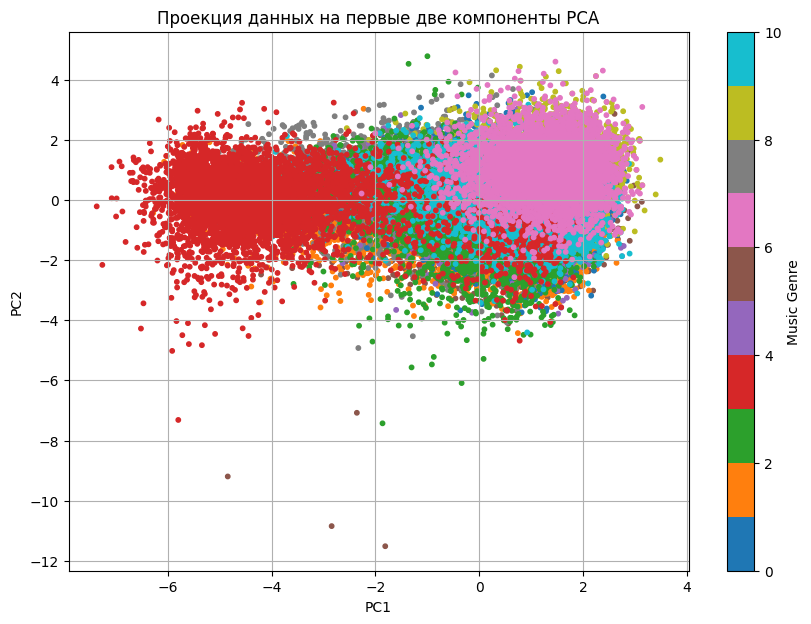

In [18]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance_ratio)+1), explained_variance_ratio)
plt.title("Доля объясненной дисперсии по компонентам")
plt.xlabel("Номер компоненты")
plt.ylabel("Доля объясненной дисперсии")

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')
plt.title("Кумулятивная объясненная дисперсия")
plt.xlabel("Количество компонент")
plt.ylabel("Кумулятивная доля дисперсии")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("Объясненная дисперсия по компонентам:")
for i, var in enumerate(explained_variance_ratio, 1):
    print(f"PC{i}: {var:.3f} ({var*100:.1f}%)")

print("\nКумулятивная объясненная дисперсия:")
for i, cum_var in enumerate(cumulative_variance, 1):
    print(f"Первые {i} компонент: {cum_var:.3f} ({cum_var*100:.1f}%)")

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize=(12, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=[f'PC{i+1}' for i in range(loadings.shape[1])],
            yticklabels=selected_features)
plt.title("Нагрузки признаков на главные компоненты")
plt.tight_layout()
plt.show()

pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_preprocessed)

plt.figure(figsize=(10, 7))
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y, cmap='tab10', s=10)
plt.title("Проекция данных на первые две компоненты PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Music Genre')
plt.grid(True)
plt.show()

Работаем с выборкой из 5000 наблюдений вместо 50005
Выполняется t-SNE с перплексией 5...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Выполняется t-SNE с перплексией 30...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Выполняется t-SNE с перплексией 50...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


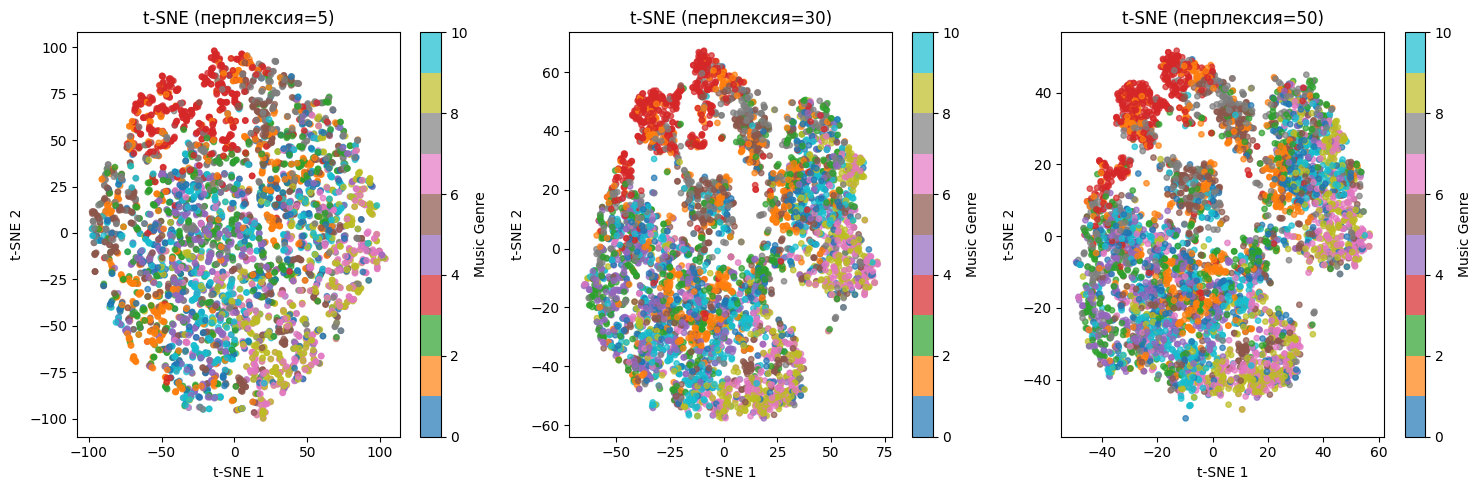

In [21]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
sample_size = 5000
sample_indices = np.random.choice(len(X_preprocessed), sample_size, replace=False)

X_sample = X_preprocessed.iloc[sample_indices]
y_sample = y.iloc[sample_indices] if y is not None else None

print(f"Работаем с выборкой из {sample_size} наблюдений вместо {len(X_preprocessed)}")

# Параметры для тестирования
perplexities = [5, 30, 50]
plt.figure(figsize=(15, 5))

for i, perplexity in enumerate(perplexities, 1):
    print(f"Выполняется t-SNE с перплексией {perplexity}...")

    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity,
                n_iter=1000, learning_rate='auto', init='random')
    X_tsne = tsne.fit_transform(X_sample)

    plt.subplot(1, 3, i)
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='tab10', s=15, alpha=0.7)
    plt.title(f't-SNE (перплексия={perplexity})')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')

    if y_sample is not None:
        plt.colorbar(scatter, label='Music Genre')

plt.tight_layout()
plt.show()

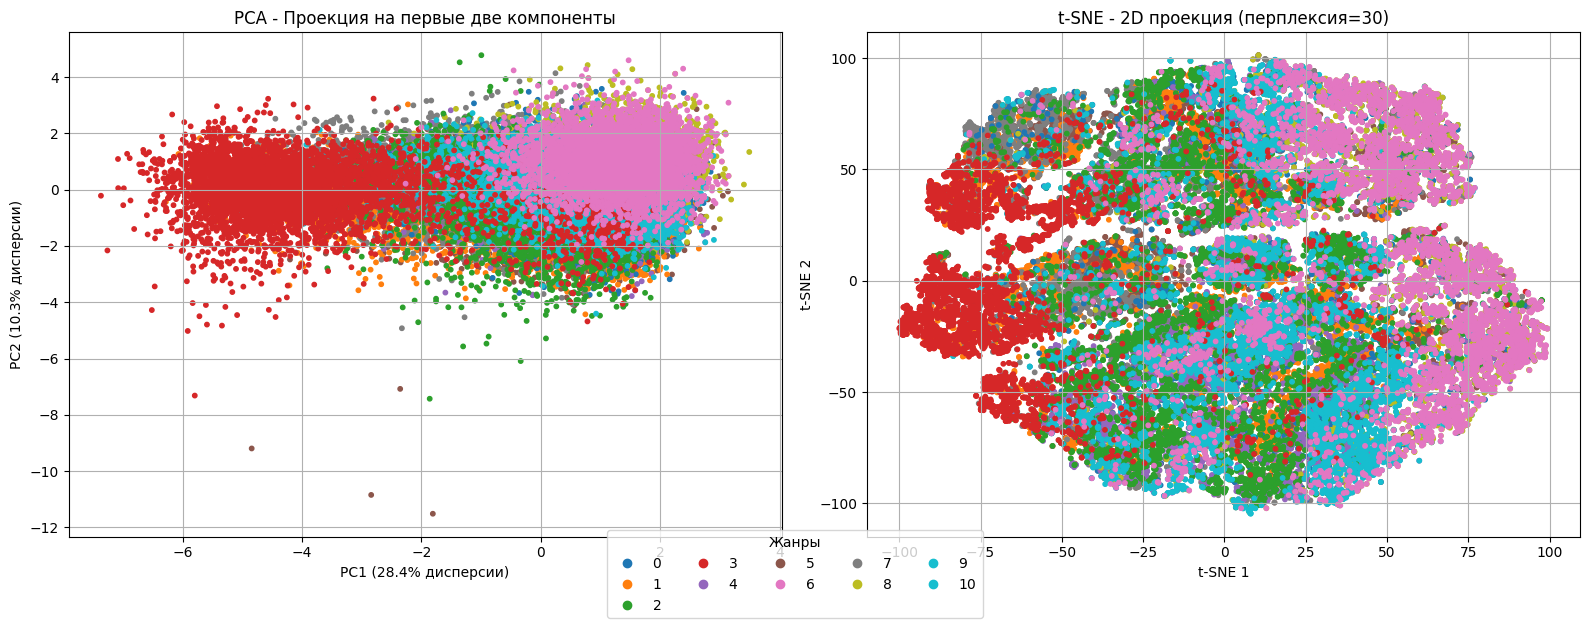

СРАВНИТЕЛЬНАЯ ТАБЛИЦА: PCA vs t-SNE
Критерий              | PCA                | t-SNE
----------------------|--------------------|--------------------
Сохранение структуры  | Глобальная         | Локальная
Интерпретируемость    | Высокая           | Низкая
Скорость выполнения   | Быстрее           | Медленнее
Параметры             | n_components      | perplexity, learning_rate
Лучше для             | Линейные данные   | Нелинейные данные
Визуализация кластеров| Умеренная         | Хорошая


In [23]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PCA
scatter1 = ax1.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y, cmap='tab10', s=10)
ax1.set_title('PCA - Проекция на первые две компоненты')
ax1.set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% дисперсии)')
ax1.set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% дисперсии)')
ax1.grid(True)

# t-SNE
tsne_best = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_best = tsne_best.fit_transform(X_preprocessed)
scatter2 = ax2.scatter(X_tsne_best[:, 0], X_tsne_best[:, 1], c=y, cmap='tab10', s=10)
ax2.set_title('t-SNE - 2D проекция (перплексия=30)')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.grid(True)

# Общая легенда
plt.figlegend(*scatter1.legend_elements(),
              title="Жанры",
              loc='lower center',
              ncol=5,
              bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()